# Eigenvalues in the wild: meeting the market

With our exercises within the simulation laboratory (`narrative_rmt_simulations.ipynb`) we earned essentially three things: (i) what are the thin-tailed **null models** (semicircle, Marchenko–Pastur, and their $q$-dependence); (ii)  **how fat tails corrupt spectra** (localised fake factors from single events, and delocalised impostors from common volatility); and (iii) a **"ranked" toolbox** of cleaning schemes tested against a spiked covatiance truth (sample < clipping < Ledoit–Wolf ≲ RIE). In this notebook we now try to apply the lessons learned tto real market data, namely **S&P constituents first, futures second.**

Here, the crucial epistemic difference with respect to the simulation lab is that, as every quant practitioner in history, we are oblivious about the udnerlying truth. Every claim we will make will have to be defended out-of-sample or by robustness across windows. It is going ti be a lot of fun (with the occasional cry here and there, of course).

Our master plan:

**Data acquisition (Part 0).** We get daily log-returns of about 200 liquid current S&P 500 consituents with their GICS sector. We clean the data dropping any with more than 5% of the days in the window. Although we download a few years worth of data, we will confine our analysis to one or two years time windows (practitioner's regime). To this, we add also visualisation tools for single asset (and cumulative) returns.  

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from rmt_lab import (                     # the same toolkit — that is the point
    sample_cov, sample_corr, mp_pdf, mp_edges,
    eigh_desc, ipr, xi_clip, lw_shrinkage, xi_rie, recompose, clean_cov,
    min_var_weights, portfolio_variance, max_to_sum_ratio, day_scale,
)

SEED = 20260901
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3 = "C0", "C1", "C2", "C3"

DATA_DIR = "data"                         # gitignored cache
print("toolkit loaded")

toolkit loaded


## Part 0 — Yearning for some data mining

How do we get our data? Remember we want to build a $X \in \mathbb{R}^{N \times T}$ matrix of log-returns (with assets in rows and time in columns, as per standard convention). Of course we want it already "clean" enough that we can actually have some trust in computing the ESD in the first place. To do so, we are going to applu a (relatively) strict protocol of data mining and hygene.

**The Protocol:**

- **What data?** ~200 liquid current S&P 500 constituents *embedded with their GICS sector*. Of ocurse, these will carry *survivorship bias*, but for our scope at the moment it is OK (although we must be aware of it, of course);
- **Where do we get them?** We use adjusted closes via `yfinance` and cache them to `data/` (gitignored, but fast to run really);
- **Returns:** we use daily log-returns. In particular, we do absolutely **no winsorising, no clipping**. These procedures would kill the tails which are curcial, especially when fat!
- **Missing data handling:** we drop any name with more than ~5% missing days in the chosen time window and we never forward-fill returns (no fabricated data, we do not the distributions behind them).
- **Which time windows?** We keep the full panel, and slice per-Part: $N \approx 200$, $T = 252$ or $504$ to get $q \approx 0.4$–$0.8$, namely a typical practitioner's regime. Of course we download much more data regardless for checks about assets' distributions.

In [18]:
UNIVERSE = {
    "Info Tech": ["AAPL","MSFT","NVDA","AVGO","ORCL","CRM","ADBE","AMD","QCOM","TXN",
                  "INTC","INTU","IBM","CSCO","ACN","AMAT","MU","LRCX","KLAC","ADI",
                  "SNPS","CDNS","PANW","ANET","NOW","APH","MSI","GLW","HPQ","NXPI"],
    "Comm Svcs": ["GOOGL","META","NFLX","DIS","CMCSA","VZ","T","TMUS","CHTR","EA",
                  "TTWO","OMC"],
    "Financials": ["BRK-B","JPM","BAC","WFC","C","GS","MS","SCHW","BLK","BX","KKR",
                   "AXP","V","MA","COF","USB","PNC","TFC","BK","AIG","MET","PRU",
                   "ALL","TRV","CB","PGR","MMC","AON","SPGI","MCO","ICE","CME"],
    "Health Care": ["LLY","UNH","JNJ","ABBV","MRK","PFE","TMO","ABT","DHR","AMGN",
                    "GILD","BMY","MDT","ISRG","SYK","BSX","VRTX","REGN","CI","ELV",
                    "CVS","HUM","BDX","EW","A","IDXX","MCK","HCA","ZTS"],
    "Cons Disc": ["AMZN","TSLA","HD","MCD","NKE","SBUX","LOW","TJX","BKNG","MAR",
                  "HLT","GM","F","ROST","YUM","CMG","ORLY","AZO","EBAY","DHI",
                  "LEN","RCL"],
    "Cons Staples": ["PG","KO","PEP","COST","WMT","PM","MO","MDLZ","CL","KMB","GIS",
                     "SYY","KR","STZ","HSY","TGT","DG","DLTR","EL"],
    "Energy": ["XOM","CVX","COP","SLB","EOG","MPC","PSX","VLO","OXY","HAL","WMB",
               "KMI","OKE","DVN","BKR"],
    "Industrials": ["CAT","DE","HON","UNP","UPS","FDX","BA","LMT","RTX","NOC","GD",
                    "GE","MMM","EMR","ETN","ITW","PH","CMI","CSX","NSC","WM","RSG",
                    "PCAR","ROK","DOV","AME","URI","PWR"],
    "Materials": ["LIN","APD","SHW","ECL","FCX","NEM","NUE","DD","PPG","VMC","MLM"],
    "Utilities": ["NEE","DUK","SO","D","AEP","EXC","SRE","XEL","ED","PEG","WEC","ES"],
    "Real Estate": ["PLD","AMT","CCI","EQIX","SPG","O","PSA","WELL","DLR","AVB"],
}
SECTOR_OF = {t: s for s, ts in UNIVERSE.items() for t in ts}
TICKERS = sorted(SECTOR_OF)
START = "2010-01-01"

print(f"{len(TICKERS)} tickers across {len(UNIVERSE)} sectors:")
for s, ts in UNIVERSE.items():
    print(f"  {s:14s} {len(ts):3d}")

220 tickers across 11 sectors:
  Info Tech       30
  Comm Svcs       12
  Financials      32
  Health Care     29
  Cons Disc       22
  Cons Staples    19
  Energy          15
  Industrials     28
  Materials       11
  Utilities       12
  Real Estate     10


In [19]:
FORCE_REFRESH = False
DATA_DIR = os.path.abspath(DATA_DIR)                 # pin it: cwd varies across IDEs
os.makedirs(DATA_DIR, exist_ok=True)
print(f"working dir : {os.getcwd()}")
print(f"cache dir   : {DATA_DIR}")
CACHE = os.path.join(DATA_DIR, "sp_prices.parquet")
CACHE_PKL = os.path.join(DATA_DIR, "sp_prices.pkl")   # fallback if pyarrow is absent

def fetch_prices(tickers, start, force=False):
    if not force:
        for path, reader in ((CACHE, pd.read_parquet), (CACHE_PKL, pd.read_pickle)):
            if os.path.exists(path):
                px = reader(path)
                print(f"loaded cache {path}: {px.shape[1]} names x {px.shape[0]} days "
                      f"({px.index[0].date()} to {px.index[-1].date()})")
                return px
    try:
        import io, logging, contextlib
        import yfinance as yf
        logging.getLogger("yfinance").setLevel(logging.CRITICAL)
        with contextlib.redirect_stderr(io.StringIO()):          # yahoo failures are noisy
            raw = yf.download(tickers, start=start, auto_adjust=True,
                              progress=False, threads=True)
        px = raw["Close"].sort_index()
        px = px.dropna(axis=1, how="all")
        if px.empty:
            raise RuntimeError("download returned nothing")
    except Exception as e:
        print(f"OFFLINE or download failed ({type(e).__name__}).")
        print("Run this cell once on a connected machine to build the cache; "
              "everything downstream will then work from data/ with no network.")
        return None
    try:
        px.to_parquet(CACHE)
        written = CACHE
    except Exception as e:
        print(f"parquet write failed ({type(e).__name__}: {e}) -> falling back to pickle")
        px.to_pickle(CACHE_PKL)
        written = CACHE_PKL
    ok = os.path.exists(written) and os.path.getsize(written) > 0
    print(f"cache written: {written}  ({os.path.getsize(written)/1e6:.1f} MB)" if ok
          else f"CACHE WRITE FAILED at {written} — check permissions/path")
    print(f"{px.shape[1]} names x {px.shape[0]} days ({px.index[0].date()} to {px.index[-1].date()})")
    return px

px = fetch_prices(TICKERS, START, force=FORCE_REFRESH)

working dir : c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails
cache dir   : c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails\data
loaded cache c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails\data\sp_prices.pkl: 218 names x 4193 days (2010-01-04 to 2026-09-03)


In [20]:
if px is None:
    print("no data yet - nothing to inspect")
else:
    first_day = px.apply(lambda s: s.first_valid_index())
    missing = px.isna().mean()
    report = pd.DataFrame({"first date": first_day.dt.date, "missing %": (100*missing).round(1),
                           "sector": pd.Series(SECTOR_OF)})
    print(f"data requested: {len(TICKERS)}   delivered: {px.shape[1]}")
    late = report.sort_values("first date", ascending=False).head(10)
    print("\nten latest listings (they sit out early windows):")
    display(late)
    absent = sorted(set(TICKERS) - set(px.columns))
    print("not delivered by yahoo at all:", absent if absent else "none")

data requested: 220   delivered: 218

ten latest listings (they sit out early windows):


,first date,missing %,sector
EA,2026-07-17,99.9,Comm Svcs
AVB,2026-07-17,99.4,Real Estate
ANET,2014-06-06,26.5,Info Tech
HLT,2013-12-12,23.7,Cons Disc
ZTS,2013-02-01,18.5,Health Care
ABBV,2013-01-02,18.0,Health Care
PANW,2012-07-20,15.3,Info Tech
NOW,2012-06-29,15.0,Info Tech
META,2012-05-18,14.3,Comm Svcs
PSX,2012-04-12,13.7,Energy


not delivered by yahoo at all: ['BK', 'MMC']


In [21]:
if px is not None:
    rets_log = np.log(px).diff().iloc[1:]      # default: time aggregation, tails, spectra
    rets_net = px.pct_change().iloc[1:]        # net (= raw = simple): aggregates across ASSETS
    rets_full = rets_log                       # back-compat alias used below

def load_returns(start, end, max_missing=0.05, kind="log", verbose=True):
    """Window -> (X, names, dates): X is (N, T), module convention (assets in rows).
    kind='log' (default) or 'net'. Only net returns aggregate linearly across assets,
    so portfolio accounting (Part 5) uses net; daily they differ at O(r^2)."""
    src = rets_log if kind == "log" else rets_net
    r = src.loc[start:end]
    keep = r.columns[r.isna().mean() <= max_missing]
    r = r[keep].dropna(axis=0, how="any")
    X = r.to_numpy().T
    if verbose:
        n, t = X.shape
        print(f"[{start} to {end}]  N = {n}  T = {t}  q = N/T = {n/t:.4f}   "
              f"(dropped {len(src.columns) - n} names, kind={kind})")
    return X, list(r.columns), r.index

if px is not None:
    X21, names21, dates21 = load_returns("2021-01-01", "2022-12-31")
    X15, names15, dates15 = load_returns("2015-01-01", "2016-12-31")
else:
    print("no data yet - loader defined, demo skipped")

[2021-01-01 to 2022-12-31]  N = 216  T = 503  q = N/T = 0.4294   (dropped 2 names, kind=log)
[2015-01-01 to 2016-12-31]  N = 216  T = 504  q = N/T = 0.4286   (dropped 2 names, kind=log)


Now a bit of visualisation. In order: (i) cumulative log returns (equal weights) and cross-section mean aboslute deviation (MAD); (ii) single asset visualisation of $P(|r| > x)$ to look into the (essentiallu ubiquitous) presence of fat tails. 

[2010-01-01 to None]  N = 201  T = 4188  q = N/T = 0.0480   (dropped 17 names, kind=log)


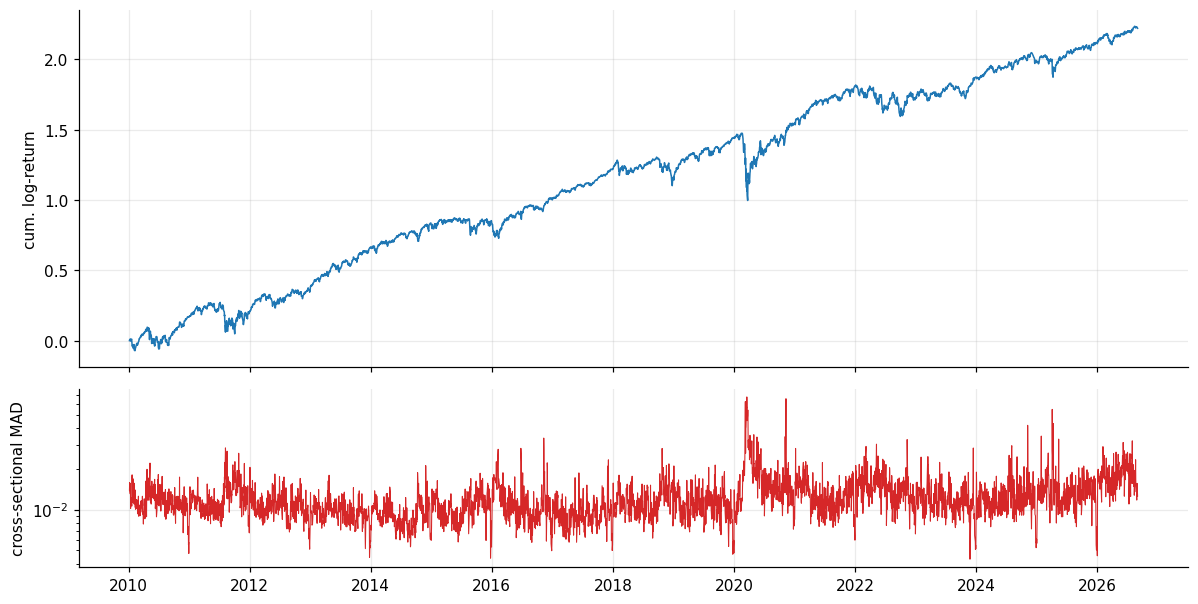

In [22]:
if px is not None:
    Xall, names_all, dates_all = load_returns(START, None, max_missing=0.02, verbose=True)
    eq_weight = Xall.mean(axis=0).cumsum()
    disp = np.sqrt(np.pi / 2.0) * np.mean(np.abs(Xall - np.mean(Xall, axis=0)), axis=0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(dates_all, eq_weight, color=C0, lw=1.0)
    ax1.set_ylabel("cum. log-return")
    ax2.semilogy(dates_all, disp, color=C3, lw=0.7)
    ax2.set_ylabel("cross-sectional MAD")
    plt.tight_layout()

The upper panel of the plot shows the overall growth of S&P 500 cumulative returns, so really nothing new there. Now, the lower pnale shows instead the cross-section MAD of the log-returns. This is a proxy for the $\sigma_t$ of Part 5 of `narrative_rmt_simulations.ipynb`, i.e., the common variance within the market.

Now, if we were to pick a single stock. Would its return dsipaly a fat tail? And if so, in which regime? We show this below for AMZ (just change the name of the stock to see a different one). We also (i) distinguish between positive and negative tails (asymmetry is always information after all), and also show the share of the fourth-moment sum owned by the single largest day ($R_4$) and the three largest days themselves.

R4: 0.07
three largest |moves| — investigate, never delete:
   2022-04-29   -0.151
   2012-04-27   +0.146
   2026-07-31   +0.143


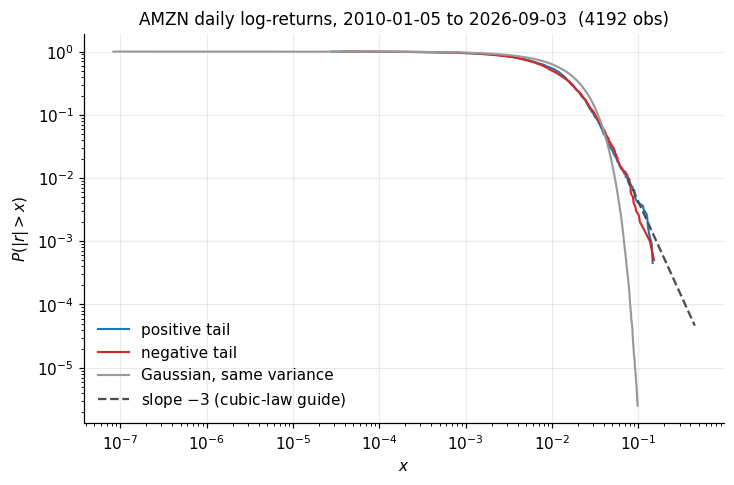

In [23]:
TICKER = "AMZN"                    # <- change me and re-run

if px is None:
    print("no data yet")
else:
    r = rets_full[TICKER].dropna()
    pos = np.sort(r[r > 0].to_numpy())
    neg = np.sort(-r[r < 0].to_numpy())
    rng_tail = np.random.default_rng(0)
    gauss = np.sort(np.abs(rng_tail.standard_normal(400_000) * r.std()))

    def ccdf(a):
        return a, 1.0 - np.arange(1, a.size + 1) / (a.size + 1)

    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for a, c_, lab in ((pos, C0, "positive tail"), (neg, C3, "negative tail"),
                       (gauss, "0.6", "Gaussian, same variance")):
        x, s = ccdf(a)
        ax.loglog(x, s, color=c_, lw=1.4, label=lab)
    x0 = np.quantile(np.concatenate([pos, neg]), 0.99)
    xg = np.array([x0, x0 * 6])
    ax.loglog(xg, 0.01 * (xg / x0) ** (-3.0), ls="--", color="0.3",
              label=r"slope $-3$ (cubic-law guide)")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$P(|r| > x)$")
    ax.set_title(f"{TICKER} daily log-returns, {r.index[0].date()} to {r.index[-1].date()}  "
                 f"({r.size} obs)")
    ax.legend()

    r4 = max_to_sum_ratio(r.to_numpy(), 4)[-1]
    print(f"R4: {r4:.2f}")
    print("three largest |moves| — investigate, never delete:")
    for d, v in r.abs().nlargest(3).items():
        print(f"   {d.date()}   {r[d]:+.3f}")

## Part 1 — A first ESD: S&P vs MP

Alright, time to get into it. To wit, enough foreplay. We now take a  windown, build the sample **correlation** matrix (unit diagonal, so that in a perfect world MP applied with $\sigma^2 = 1$) and just ask: *how much of this spectrum is
explained by "nothing is going on, i.e., randomness"?*

To investigate this, we effectively employ two thresholds, each against the **same Gaussian, stationary null**. We will challange this null later on in Part 3 and Part 4. In particular, the thresholds are:

1. **The naive MP edge** $(1+\sqrt q)^2$, namely the textbook line. We will see how this fails since the market absorbs a large share of the total variance, leaving the noise band narrower than $\sigma^2 = 1$ assumes;
2. **An effective edge**. This is build by removing the market mode and then spreading the residual trace over the remaining $N-1$ directions, i.e., $\sigma^2_{\rm eff} = (N-\lambda_1)/(N-1)$ with $q_{\rm eff} = (N-1)/T$. Then one just recimputes the edge. See Laloux, Cizeau, Bouchaud, and Potters (1999), PRL 83, 1467 — *Noise dressing of financial correlation matrices*. 


Finally, we will employ **TW / LDT ** to try to give essentially a p-value rather than a yes/no to any outliers.

AH! A notation statement. In `narrative_rmt_simulations.ipynb` we used the notation $\lambda_{\rm max}$ for the top realised eigenvalue. From here on out we will use instead $\lambda_1$ and in general we will label in decreasing order of magnitude $\lambda_1 > \lambda_2 >\, ...\, > \lambda_{N}$.

In [31]:
def mp_fit_k(lam, n, t, k=1):
    """Effective MP null after removing the k largest modes
      residual trace spread over the remaining n-k directions,
      q_eff = (n-k)/T."""
    sig2 = (lam.sum() - lam[:k].sum()) / (n - k)
    q_eff = (n - k) / t
    return sig2, q_eff, mp_edges(q_eff, sig2)[1]

def tw_threshold(n, t, sig2=1.0, quantile=0.9794):
    """Johnstone centering/scaling for the top Wishart eigenvalue; default quantile
    is the 95th percentile of TW (beta=1)."""
    mu = (np.sqrt(t - 1) + np.sqrt(n)) ** 2 / t
    sc = (np.sqrt(t - 1) + np.sqrt(n)) / t * (1 / np.sqrt(t - 1) + 1 / np.sqrt(n)) ** (1 / 3)
    return sig2 * (mu + quantile * sc)

def psi_plus(x, q, sig2=1.0, npts=2000):
    """Right large-deviation rate: P(lambda > x) ~ exp(-N * Psi_+(x))."""
    lm, lp = mp_edges(q, sig2)
    x = np.atleast_1d(np.asarray(x, float))
    out = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi > lp:
            tt = np.linspace(lp, xi, npts)
            out[i] = 0.5 * np.trapezoid(np.sqrt((tt - lm) * (tt - lp)) / (q * sig2 * tt), tt)
    return out

In [36]:
if px is not None:
    WIN_DAYS = 504                                   # ~2 years; one edit changes the window easily
    w_end, w_start = rets_log.index[-1], rets_log.index[-WIN_DAYS]
    Xw, names_w, dates_w = load_returns(w_start, w_end, max_missing=0.02)

    Cw = sample_corr(Xw, demean=True)
    lam_w, U_w = eigh_desc(Cw)
    Nw, Tw = Xw.shape
    qw = Nw / Tw
    rho_bar = Cw[np.triu_indices(Nw, 1)].mean()

    print(f"window: {dates_w[0].date()} to {dates_w[-1].date()}")
    print(f"mean pairwise correlation rho_bar = {rho_bar:.3f}")
    print(f"lambda_1 = {lam_w[0]:.1f}")
    print(f"lambda_1 explains {100 * lam_w[0] / Nw:.1f}% of the total variance "
          f"(trace = N = {Nw})")

[2024-08-30 00:00:00 to 2026-09-03 00:00:00]  N = 216  T = 501  q = N/T = 0.4311   (dropped 2 names, kind=log)
window: 2024-08-30 to 2026-08-31
mean pairwise correlation rho_bar = 0.193
lambda_1 = 47.2
lambda_1 explains 21.9% of the total variance (trace = N = 216)


above naive edge      : 10
above effective edge  : 13
above TW 95%  (effective edge) : 13


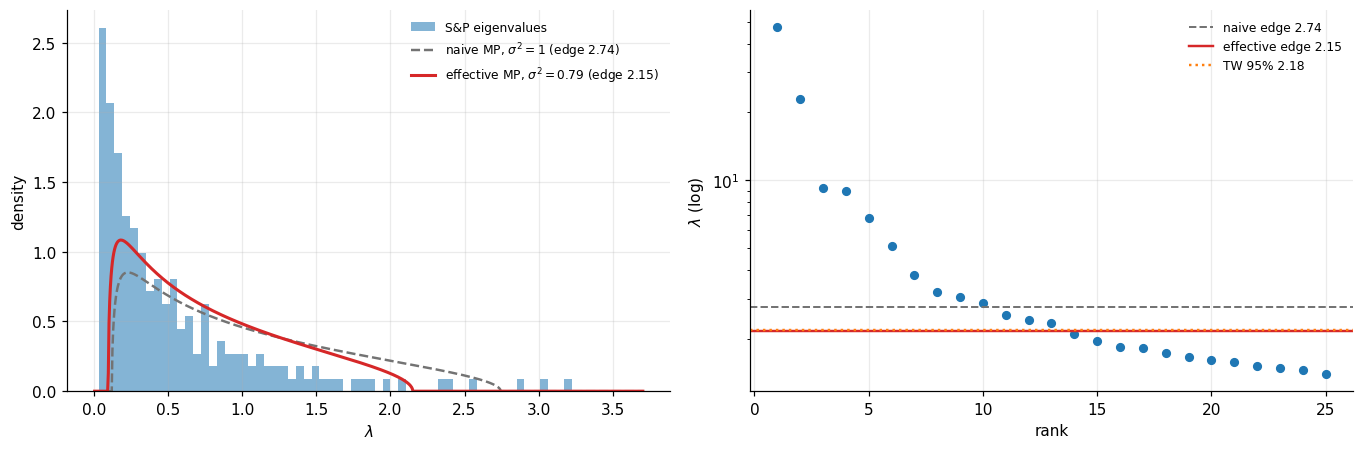

In [34]:
if px is not None:
    edge_naive = mp_edges(qw, 1.0)[1]
    sig2_eff, q_eff, edge_eff = mp_fit_k(lam_w, Nw, Tw, k=1)
    tw95 = tw_threshold(Nw - 1, Tw, sig2_eff)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

    xs = np.linspace(1e-3, edge_naive * 1.35, 800)
    ax1.hist(lam_w[lam_w < edge_naive * 1.35], bins=60, density=True, color=C0,
             alpha=0.55, label="S&P eigenvalues")
    ax1.plot(xs, mp_pdf(xs, qw, 1.0), color="0.45", lw=1.6, ls="--",
             label=rf"naive MP, $\sigma^2=1$ (edge {edge_naive:.2f})")
    ax1.plot(xs, mp_pdf(xs, q_eff, sig2_eff), color=C3, lw=2,
             label=rf"effective MP, $\sigma^2={sig2_eff:.2f}$ (edge {edge_eff:.2f})")
    ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("density")
    ax1.legend(fontsize=8)

    top = 25
    ax2.semilogy(np.arange(1, top + 1), lam_w[:top], "o", color=C0, ms=5)
    ax2.axhline(edge_naive, color="0.45", ls="--", lw=1.3, label=f"naive edge {edge_naive:.2f}")
    ax2.axhline(edge_eff, color=C3, lw=1.6, label=f"effective edge {edge_eff:.2f}")
    ax2.axhline(tw95, color=C1, ls=":", lw=1.6, label=f"TW 95% {tw95:.2f}")
    ax2.set_xlabel("rank"); ax2.set_ylabel(r"$\lambda$ (log)")
    ax2.legend(fontsize=8)
    plt.tight_layout()

    n_naive = int((lam_w > edge_naive).sum())
    n_eff = int((lam_w > edge_eff).sum())
    n_tw = int((lam_w > tw95).sum())
    print(f"above naive edge      : {n_naive}")
    print(f"above effective edge  : {n_eff}")
    print(f"above TW 95%  (effective edge) : {n_tw}")

The plot above shows: (i) the bulk of the S&P EDS superimposed with the MP distribution with the naive and effective edges (left panel); and (ii) the top part of the spectrum (i.e., the top 25 entries) with the naive and effective edges, as well as the TW 95% confidence band.

It is clear from the plot that **MP does not seem to be a good fit if we only remove the top market mode**. In fact the left plot recalls the elliptical fat-tailed plot we obtained in Part 5 of `narrative_rmt_simulations.ipynb`. We will of course investigate this.

Additioanlly, a large portion of the eigenvalues are concentrate to the left and quite a few show up as signifcant outliers. Now, are they genuine outliers even considering LDT?

In [27]:
if px is not None:
    k_show = max(n_eff + 3, 12)
    ld = psi_plus(lam_w[:k_show], q_eff, sig2_eff)
    tbl = pd.DataFrame({
        "lambda": lam_w[:k_show].round(3),
        "> eff. edge": np.where(lam_w[:k_show] > edge_eff, "yes", "-"),
        "LD cost N*Psi": (Nw * ld).round(1),
        "IPR": [float(ipr(U_w[:, i])) for i in range(k_show)],
        "top |loading|": [names_w[int(np.argmax(np.abs(U_w[:, i])))] for i in range(k_show)],
        "top sector": [SECTOR_OF.get(names_w[int(np.argmax(np.abs(U_w[:, i])))], "?")
                       for i in range(k_show)],
    }, index=[f"lam_{i+1}" for i in range(k_show)])
    print(f"delocalised reference 3/N = {3/Nw:.4f}   (IPR near it = spread over everything; "
          f"near 1 = one stock)")
    display(tbl.style.format({"IPR": "{:.4f}"}))

delocalised reference 3/N = 0.0139   (IPR near it = spread over everything; near 1 = one stock)


C:\Users\mrcga\AppData\Local\Temp\ipykernel_17980\2339377894.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "IPR": [float(ipr(U_w[:, i])) for i in range(k_show)],


,lambda,> eff. edge,LD cost N*Psi,IPR,top |loading|,top sector
lam_1,47.213000,yes,13214.000000,0.0068,ITW,Industrials
lam_2,22.750000,yes,5638.700000,0.0109,ED,Utilities
lam_3,9.258000,yes,1649.000000,0.0380,COP,Energy
lam_4,8.982000,yes,1571.800000,0.0170,NOW,Info Tech
lam_5,6.830000,yes,987.600000,0.0108,PEG,Utilities
lam_6,5.100000,yes,548.700000,0.0119,WFC,Financials
lam_7,3.828000,yes,259.300000,0.0188,ELV,Health Care
lam_8,3.225000,yes,140.500000,0.0152,CVS,Health Care
lam_9,3.041000,yes,107.900000,0.0165,UNH,Health Care
lam_10,2.880000,yes,81.300000,0.0208,NOC,Industrials


above naive edge      : 1
above effective edge  : 13
above TW 95%  (effective edge) : 13


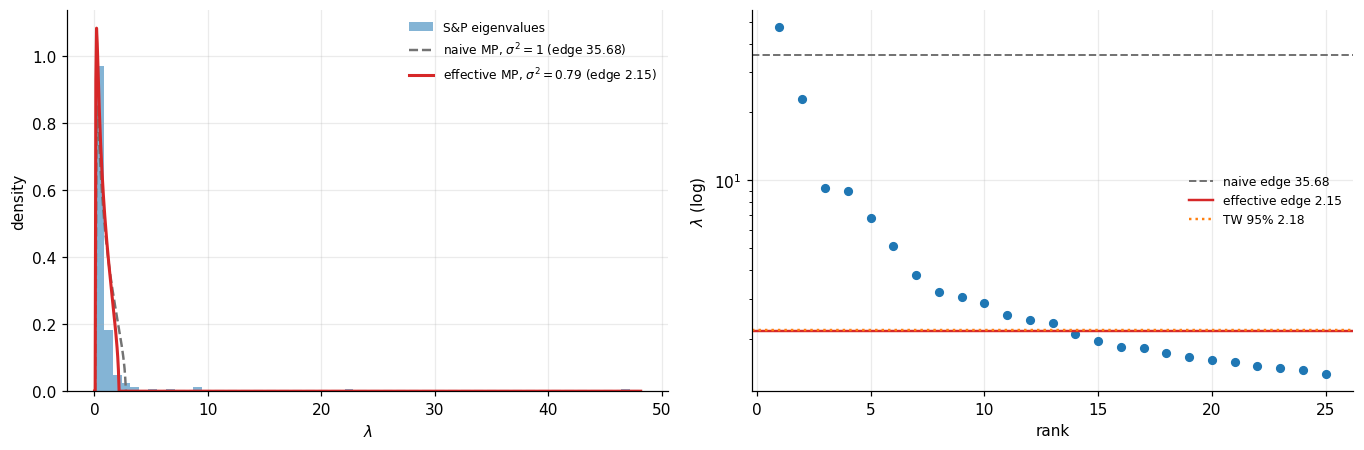

In [ ]:
if px is not None:
    edge_naive = mp_edges(qw, 1)[1]
    sig2_eff, q_eff, edge_eff = mp_fit_k(lam_w, Nw, Tw, k=13)
    tw95 = tw_threshold(Nw - 1, Tw, sig2_eff)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

    xs = np.linspace(1e-3, edge_naive * 1.35, 800)
    ax1.hist(lam_w[lam_w < edge_naive * 1.35], bins=60, density=True, color=C0,
             alpha=0.55, label="S&P eigenvalues")
    ax1.plot(xs, mp_pdf(xs, qw, 1.0), color="0.45", lw=1.6, ls="--",
             label=rf"naive MP, $\sigma^2=1$ (edge {edge_naive:.2f})")
    ax1.plot(xs, mp_pdf(xs, q_eff, sig2_eff), color=C3, lw=2,
             label=rf"effective MP, $\sigma^2={sig2_eff:.2f}$ (edge {edge_eff:.2f})")
    ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("density")
    ax1.legend(fontsize=8)

    top = 25
    ax2.semilogy(np.arange(1, top + 1), lam_w[:top], "o", color=C0, ms=5)
    ax2.axhline(edge_naive, color="0.45", ls="--", lw=1.3, label=f"naive edge {edge_naive:.2f}")
    ax2.axhline(edge_eff, color=C3, lw=1.6, label=f"effective edge {edge_eff:.2f}")
    ax2.axhline(tw95, color=C1, ls=":", lw=1.6, label=f"TW 95% {tw95:.2f}")
    ax2.set_xlabel("rank"); ax2.set_ylabel(r"$\lambda$ (log)")
    ax2.legend(fontsize=8)
    plt.tight_layout()

    n_naive = int((lam_w > edge_naive).sum())
    n_eff = int((lam_w > edge_eff).sum())
    n_tw = int((lam_w > tw95).sum())
    print(f"above naive edge      : {n_naive}")
    print(f"above effective edge  : {n_eff}")
    print(f"above TW 95%  (effective edge) : {n_tw}")

We see that all the "above the edge" eigenvalues are moved enough from the threshold to be identified as signal (within a Gaussian noise world) even when considering LDT. What happens to out distribution of the Bulk if we remove them all now?

### 1.1 — Calibration: what would we see if we *knew* the answer?

The counts above are only as good as the null they price. So, a control experiment
with the truth in hand: the same $N$, $T$ and market strength, **four** planted
factors, run twice — once with Gaussian entries (the null's own assumptions) and once
with elliptical $t(5)$ (the market's assumptions, from Part 5 of the simulation lab).
This tells us how to *read* the S&P number: what a detection count looks like when it
is honest, and what it looks like when fat tails inflate it.

In [30]:
from rmt_lab import spiked_cov, returns_student, returns_gaussian

N_c, T_c, K_TRUE = 200, 504, 4
rng_c = np.random.default_rng(11)
C_c, _ = spiked_cov(N_c, [70.0, 6.0, 4.0, 3.0], rng_c, market=True)   # market + 3 sectors

rows = []
for lab, Xc in (("Gaussian (null's world)", returns_gaussian(N_c, T_c, rng_c, cov=C_c)),
                ("elliptical t(3) (market's world)",
                 returns_student(N_c, T_c, 3.0, rng_c, cov=C_c, elliptical=True))):
    lam_c, _ = eigh_desc(sample_corr(Xc, demean=True))
    e_naive = mp_edges(N_c / T_c, 1.0)[1]
    s2_c, q_c, e_eff = mp_fit_k(lam_c, N_c, T_c, k=1)
    rows.append({"world": lab, "true factors": K_TRUE, "lambda_1": round(lam_c[0], 1),
                 "above naive edge": int((lam_c > e_naive).sum()),
                 "sigma2_eff": round(s2_c, 3),
                 "above effective edge": int((lam_c > e_eff).sum()),
                 "above TW95": int((lam_c > tw_threshold(N_c - 1, T_c, s2_c)).sum())})
pd.DataFrame(rows).set_index("world")

,true factors,lambda_1,above naive edge,sigma2_eff,above effective edge,above TW95
world,,,,,,
Gaussian (null's world),4,50.9,3,0.749,4,4
elliptical t(3) (market's world),4,48.0,12,0.764,17,17


### 1.2 — Reading the two tables together

The control settles how much trust each column deserves, before we say a word about
the S&P numbers:

- **The naive edge under-detects**, and structurally so: with a market mode swallowing
  a large share of the trace, $\sigma^2 = 1$ describes a noise band wider than the one
  the residual directions actually live in. Anyone counting factors against
  $(1+\sqrt q)^2$ on a correlation matrix is using a ruler the market mode already
  bent.
- **The effective edge is calibrated — in the null's own world.** With Gaussian
  entries it recovers exactly the planted count. That is the good news, and it is
  worth stating precisely: *when the assumptions hold, this machinery is not
  approximately right, it is right.*
- **Fat tails inflate the count, badly.** Same truth, same $q$, elliptical $t(5)$
  instead of Gaussian: the effective edge reports several times the planted number.
  Not an estimation subtlety — the same mechanism the simulation lab's Part 5 showed
  with heatmaps, now costing us specific false factors.

So any S&P count read off the effective edge is an **upper bound on the number of real
factors**, contaminated by whatever the tails contribute. Two lines of defence follow,
and they are the next two Parts: the **IPR** column above (a localised eigenvector is
one stock, not a factor — Part 2 puts names and sectors to every mode), and
**volatility filtering** (Part 3), which removes the common-scale mechanism and asks
which outliers survive. Only what survives both is allowed to be called a factor, and
only then does Part 4 get to ask whether it *persists*.